In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
   # for filename in filenames:
       # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install matplotlib
!pip install --upgrade librosa

In [3]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-04-24 06:52:43.898158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777013564.081748      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777013564.139659      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777013564.598770      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777013564.598813      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777013564.598815      22 computation_placer.cc:177] computation placer alr

In [4]:

base_path="/kaggle/input/datasets/soumyadebmukherjee/heart-and-lung-sounds-dataset/HLS-CMDS Heart and Lung Sounds Dataset Recorded from a Clinical Manikin using Digital Stethoscope"
mix_path=base_path+"/Mix/Mix"
files=os.listdir(mix_path)
print("Total files:",len(files))
print(files[:10])

Total files: 436
['M0115.wav', 'H0104.wav', 'H0013.wav', 'L0070.wav', 'H0017.wav', 'L0024.wav', 'M0109.wav', 'H0109.wav', 'H0002.wav', 'H0108.wav']


In [5]:

file_path=mix_path+'/'+files[0]
y,sr=librosa.load(file_path,sr=None)
print("Shape:",y.shape)
print("Sample rate:",sr)

Shape: (60000,)
Sample rate: 4000


In [6]:
import IPython.display as ipd
ipd.Audio(file_path)

In [7]:
#DATA AUGMENTATION
def add_noise(audio):
    noise = np.random.randn(len(audio))
    return audio + 0.003 * noise

def time_shift(audio):
    shift = np.random.randint(-int(0.2 * len(audio)), int(0.2 * len(audio)))
    return np.roll(audio, shift)

def pitch_shift(audio, sr):
    steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

def time_stretch(audio):
    rate = np.random.uniform(0.8, 1.2)
    return librosa.effects.time_stretch(audio, rate=rate)

def spec_augment(spec):
    spec = spec.copy()

    # frequency mask
    f = np.random.randint(0, 20)
    f0 = np.random.randint(0, spec.shape[0] - f)
    spec[f0:f0+f, :] = 0

    # time mask
    t = np.random.randint(0, 20)
    t0 = np.random.randint(0, spec.shape[1] - t)
    spec[:, t0:t0+t] = 0

    return spec

In [8]:
df = pd.read_csv(base_path + "/Mix.csv")
df['file_name'] = df['Mixed Sound ID'] + ".wav"

In [9]:
X = []
y = []

for i in range(len(df)):
    try:
        file = df['file_name'][i]
        file_path = os.path.join(mix_path, file)

        audio, sr = librosa.load(file_path, sr=None)

        # Augmented versions
        audios = [
            audio,
            add_noise(audio),
            time_shift(audio),
            pitch_shift(audio, sr),
            time_stretch(audio)
        ]

        for aug_audio in audios:

            # Log-Mel Spectrogram (BEST for CNN)
            mel = librosa.feature.melspectrogram(
                y=aug_audio, sr=sr, n_mels=256
            )
            mel_db = librosa.power_to_db(mel)
            mel_db = spec_augment(mel_db)
            # Normalize per sample
            mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

            # Resize to (128,128)
            if mel_db.shape[1] < 128:
                pad = 128 - mel_db.shape[1]
                mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode='constant')
            else:
                mel_db = mel_db[:, :128]

            mel_db = mel_db[:128, :]

            X.append(mel_db)
            y.append(df['Lung Sound Type'][i])

    except Exception as e:
        print("Error:", e)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)

X shape: (725, 128, 128)


In [10]:
import pandas as pd
df=pd.read_csv(base_path+"/Mix.csv")
df.head

<bound method NDFrame.head of     Gender       Heart Sound Type  Lung Sound Type Location Heart Sound ID  \
0        F   Late Systolic Murmur          Rhonchi     LUSB          H0001   
1        F                     S3           Normal      RLA          H0002   
2        M    Atrial Fibrillation           Normal      LMA          H0003   
3        F                     S3  Coarse Crackles     Apex          H0004   
4        M               AV Block    Fine Crackles     RUSB          H0005   
..     ...                    ...              ...      ...            ...   
140      M                     S4         Wheezing     Apex          H0141   
141      F    Mid Systolic Murmur           Normal      RMA          H0142   
142      F  Early Systolic Murmur         Wheezing      RLA          H0143   
143      F               AV Block           Normal      LUA          H0144   
144      M  Late Diastolic Murmur           Normal     RUSB          H0145   

    Lung Sound ID Mixed Sound ID 

In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(le.classes_)
print(le.classes_)

['Coarse Crackles' 'Fine Crackles' 'Normal' 'Pleural Rub' 'Rhonchi'
 'Wheezing']


In [12]:
#normalize and train
mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

X = X.reshape(X.shape[0], 128, 128, 1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [13]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128,128,1)),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

I0000 00:00:1777013615.618742      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777013615.624713      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [15]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

I0000 00:00:1777013617.551974      96 service.cc:152] XLA service 0x7f1b70022900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777013617.552021      96 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777013617.552028      96 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777013617.721575      96 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2188 - loss: 1.7980

I0000 00:00:1777013619.505974      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.2041 - loss: 1.7945
Accuracy: 0.19310344755649567


In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=800,
    batch_size=4,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/800


2026-04-24 06:53:44.520801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 06:53:44.662868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.2050 - loss: 2.1470 - val_accuracy: 0.2000 - val_loss: 1.7834 - learning_rate: 0.0010
Epoch 2/800
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1520 - loss: 1.8232 - val_accuracy: 0.1655 - val_loss: 1.8478 - learning_rate: 0.0010
Epoch 3/800
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1693 - loss: 1.8164 - val_accuracy: 0.1862 - val_loss: 1.7592 - learning_rate: 0.0010
Epoch 4/800
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1970 - loss: 1.7961 - val_accuracy: 0.2621 - val_loss: 1.7620 - learning_rate: 0.0010
Epoch 5/800
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1961 - loss: 1.7871 - val_accuracy: 0.2276 - val_loss: 1.7600 - learning_rate: 0.0010
Epoch 6/800
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1973 - loss: 1.7903 - val_accuracy: 0.2552 - val_loss: 1.7328 - learning_rate: 0.0010
Epoch 7/800
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2213 - loss: 1.7700 - val_

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step


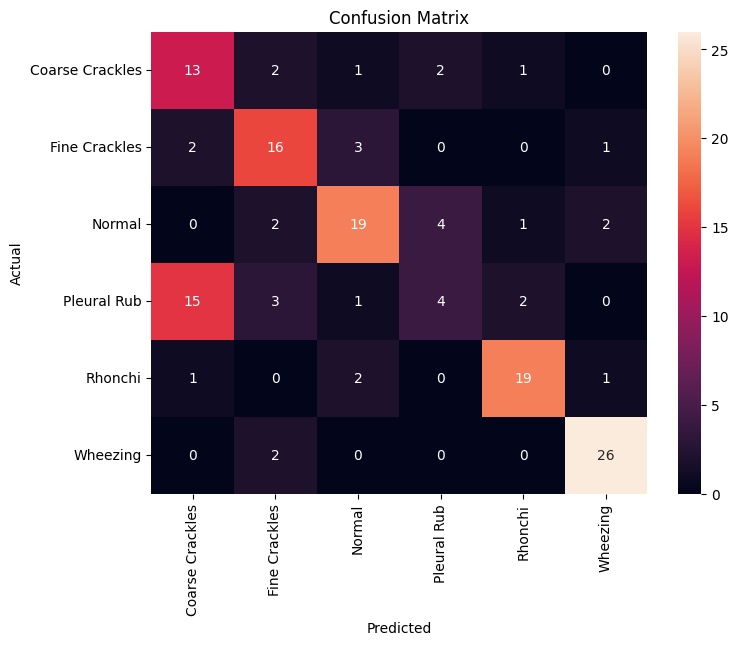

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

This project classifies lung diseases using audio recordings.
We convert audio signals into MFCC features and train a machine learning model to predict disease types.